In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import ROOT
mpl.rc('text', usetex = True)

In [3]:
def vmd_model_rho(Q2,c0,c1):
    return c0*(Q2/0.775)**c1

def vmd_model_omega(Q2,c0,c1):
    return c0*(Q2/0.782)**c1


In [4]:
# DataFrame column names
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_0_0"]

Q2_hermes = np.array([0.82, 1.19, 1.66, 3.06])
Q2_murho = np.array([1.14, 1.6, 2.8, 6.02])
Q2_omega = np.array([1.16, 1.64, 3.58, 0])
Q2_eomega = np.array([1.28, 2.0, 4.0, 0])

reaction = ["e_rho", "mu_rho", "e_omega","mu_omega"] # I output my (minimiser) filenames in a standardised way so I can loop over them
filenames = ["HERMES", "MuRho", "ElOmega", "Omega"]
masses = [775,775,782,782]
bin_size = [4,4,3,3]
Q2 = np.array([Q2_hermes,Q2_murho,Q2_eomega,Q2_omega])

R_HERMES = np.array([[0.649,0.671,0.794,1.068],[0.188,0.065,0.083,0.087]]).T
R_COMPASS = np.array([[0.724,0.930,1.227,1.200],[0.078,0.081,0.122,0.729]]).T
R_OMEGA = np.array([[0.475,0.495,0.739],[0.085,0.124,0.197]]).T
R_EOMEGA = np.array([[0.226,0.237,0.283],[0.066,0.091,0.091]]).T
N = 1000

[0.609328   0.91505537 0.87830395 0.9211467 ]


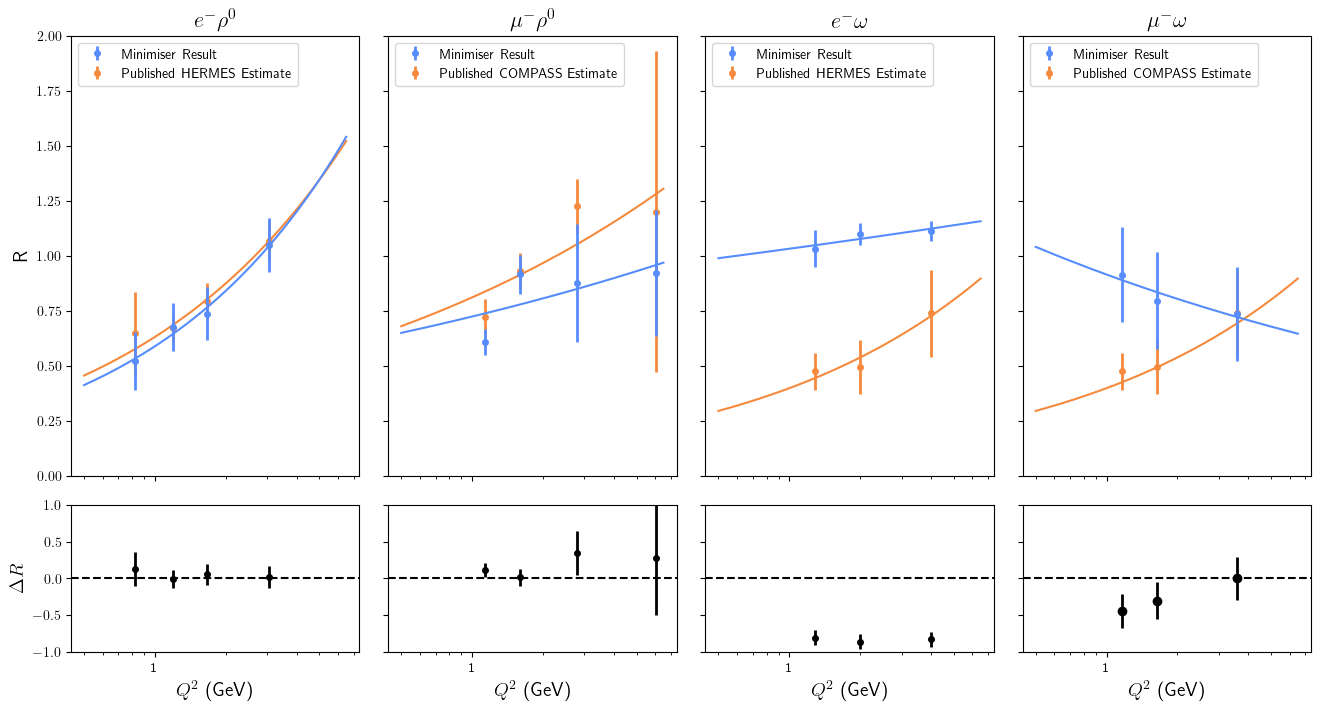

In [6]:
# Fit with cuts
R_legend = ["e^-\\rho^0", "\\mu^-\\rho^0", "e^-\\omega","\\mu^-\\omega"]
mean_and_err = np.empty((4,2))
Q2_fit = np.linspace(0.5,6.5,1000)

# -------------------------------
# NEW LAYOUT FOR THE FIRST FIGURE
# -------------------------------
fig = plt.figure(figsize=(16,8))
gs = fig.add_gridspec(
    2, 4,
    height_ratios=[3, 1],
    hspace=0.1,
    wspace=0.1
)

axL = fig.add_subplot(gs[0, 0])                    # top-left
axCL = fig.add_subplot(gs[0, 1], sharex=axL, sharey=axL)  # top-centre
axCR = fig.add_subplot(gs[0, 2], sharex=axL, sharey=axL)  # top-right
axR = fig.add_subplot(gs[0, 3], sharex=axL, sharey=axL)  # top-right
axdiffL = fig.add_subplot(gs[1, 0], sharex=axL)
axdiffCL = fig.add_subplot(gs[1, 1], sharex=axL, sharey=axdiffL)
axdiffCR = fig.add_subplot(gs[1, 2], sharex=axL, sharey=axdiffL)  # bottom spans both columns
axdiffR = fig.add_subplot(gs[1, 3], sharex=axL, sharey=axdiffL)  # bottom spans both columns

for r in range(4):
    for i in range(bin_size[r]):
        if ((r == 2 or r==3) and i == 3):
            continue

        df = ROOT.RDataFrame(
        "PartialWaves",
        "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/"
        + filenames[r] + "_bootstrap_" + str(i) + ".root"
    )
        #if r == 0:
            # df = df.Define(
            #     "RNPE",
            #     "(b_L_1_1*b_L_1_1 + b_L_1_0*b_L_1_0 + b_L_1_m1*b_L_1_m1)/"
            #     "(a_T_1_1*a_T_1_1 + a_T_1_0*a_T_1_0 + a_T_1_m1*a_T_1_m1)"
            # )
            # RNPE = df.Mean("RNPE")
            # RerrNPE = df.StdDev("RNPE")
            #
            # df = df.Define(
            #     "RUPE",
            #     "(a_L_1_1*a_L_1_1 + a_L_1_0*a_L_1_0 + a_L_1_m1*a_L_1_m1)/"
            #     "(b_T_1_1*b_T_1_1 + b_T_1_0*b_T_1_0 + b_T_1_m1*b_T_1_m1)"
            # )
            # RUPE = df.Mean("RUPE")
            # RerrUPE = df.StdDev("RUPE")
            #
            # mean_and_errNPE[i,:] = np.array([RNPE.GetValue(), RerrNPE.GetValue()])
            # mean_and_errUPE[i,:] = np.array([RUPE.GetValue(), RerrUPE.GetValue()])

        df = df.Define("R", "-H_4_0_0/H_0_0_0")
        R = df.Mean("R")
        Rerr = df.StdDev("R")
        mean_and_err[i,:] = np.array([R.GetValue(), Rerr.GetValue()])

    # ----------------
    # FITS
    # ----------------
    if r == 2 or r==3:
        if r == 2:
            mean_and_err[1,0] = 1.1
            mean_and_err[1,1] = 0.05
        popt, pcov = curve_fit(
            vmd_model_omega,
            Q2[r,:3],
            mean_and_err[:3,0],
            p0=[1, 1],
        )
        R_fit = vmd_model_omega(Q2_fit, *popt)
    else:
        popt, pcov = curve_fit(
            vmd_model_rho,
            Q2[r,:],
            mean_and_err[:,0],
            p0=[1, 1],
        )
        R_fit = vmd_model_rho(Q2_fit, *popt)

    hermes_best = vmd_model_rho(Q2_fit, 0.56, 0.47)

    popt, pcov = curve_fit(
            vmd_model_rho,
            Q2[1,:],
            R_COMPASS[:,0],
            p0=[1, 1],
        )
    compass_best = vmd_model_rho(Q2_fit,*popt)

    popt, pcov = curve_fit(
            vmd_model_omega,
            Q2[2,:3],
            R_OMEGA[:,0],
            p0=[1, 1],
        )

    omega_best = vmd_model_omega(Q2_fit,*popt)

    popt, pcov = curve_fit(
            vmd_model_omega,
            Q2[3,:3],
            R_EOMEGA[:,0],
            p0=[1, 1],
        )
    e_omega_best = vmd_model_omega(Q2_fit,*popt)


    # ----------------
    # FIRST FIGURE
    # ----------------
    if r == 0:
        # left panel: e-rho, HERMES, NPE, UPE
        p = axL.errorbar(
            Q2[r,:], mean_and_err[:,0], zorder = 5,  yerr=mean_and_err[:,1],
            fmt='.', markersize=8, elinewidth=2,
            label="Minimiser Result"
        )
        c = p.lines[0].get_color()
        axL.plot(Q2_fit, R_fit, '-', zorder = 5,  color=c)

        # HERMES on left
        p = axL.errorbar(
            Q2[r,:], R_HERMES[:,0], yerr=R_HERMES[:,1],
            fmt='.', markersize=8, elinewidth=2, label="Published HERMES Estimate"
        )
        c = p.lines[0].get_color()
        axL.plot(Q2_fit, hermes_best, '-', color=c)

        # NPE / UPE on left
        # axL.errorbar(
        #     Q2[r,:], mean_and_errNPE[:,0], yerr=mean_and_errNPE[:,1],
        #     fmt='.', markersize=8, elinewidth=2,
        #     label="$R_{{NPE}}$ MINE"
        # )
        # axL.errorbar(
        #     Q2[r,:], mean_and_errUPE[:,0], yerr=mean_and_errUPE[:,1],
        #     fmt='.', markersize=8, elinewidth=2,
        #     label="$R_{{UPE}}$ MINE"
        # )

        # ABSOLUTE difference instead of percentage
        diff = R_HERMES[:,0] - mean_and_err[:,0]
        diff_err = np.sqrt(R_HERMES[:,1]**2 + mean_and_err[:,1]**2)

    elif r == 1:
        # right panel: mu-rho
        print(mean_and_err[:,0])
        p = axCL.errorbar(
            Q2[r,:], mean_and_err[:,0], yerr=mean_and_err[:,1],
            fmt='.', markersize=8, elinewidth=2, zorder = 5, 
            label="Minimiser Result")
        c = p.lines[0].get_color()
        axCL.plot(Q2_fit, R_fit, '-', zorder = 5,  color=c)

        p = axCL.errorbar(
            Q2[r,:], R_COMPASS[:,0], yerr=R_COMPASS[:,1],
            fmt='.', markersize=8, elinewidth=2, label="Published COMPASS Estimate")
        c = p.lines[0].get_color()
        axCL.plot(Q2_fit, compass_best, '-', color=c)

        diff_muon = R_COMPASS[:,0] - mean_and_err[:,0]
        diff_muon_err = np.sqrt(R_COMPASS[:,1]**2 + mean_and_err[:,1]**2)

    elif r == 2:
        # center right panel: e-omega
        p = axCR.errorbar(
            Q2[r,:3], mean_and_err[:3,0], yerr=mean_and_err[:3,1],
            fmt='.', markersize=8, elinewidth=2, zorder = 5, 
            label="Minimiser Result")
        c = p.lines[0].get_color()
        axCR.plot(Q2_fit, R_fit, '-', zorder = 5,  color=c)

        p = axCR.errorbar(
            Q2[r,:3], R_OMEGA[:,0], yerr=R_OMEGA[:,1],
            fmt='.', markersize=8, elinewidth=2, label="Published HERMES Estimate"
        )
        c = p.lines[0].get_color()
        axCR.plot(Q2_fit, omega_best, '-', color=c)

        diff_e_omega = R_EOMEGA[:,0] - mean_and_err[:3,0]
        diff_e_omega_err = np.sqrt(R_EOMEGA[:,1]**2 + mean_and_err[:3,1]**2)

    elif r == 3:
        # right panel: mu-omega
        p = axR.errorbar(
            Q2[r,:3], mean_and_err[:3,0], yerr=mean_and_err[:3,1],
            fmt='.', markersize=8, elinewidth=2, zorder = 5, 
            label="Minimiser Result")
        c = p.lines[0].get_color()
        axR.plot(Q2_fit, R_fit, '-', zorder = 5,  color=c)

        p = axR.errorbar(
            Q2[r,:3], R_OMEGA[:,0], yerr=R_OMEGA[:,1],
            fmt='.', markersize=8, elinewidth=2, label="Published COMPASS Estimate"
        )
        c = p.lines[0].get_color()
        axR.plot(Q2_fit, omega_best, '-', color=c)

        diff_omega = R_OMEGA[:,0] - mean_and_err[:3,0]
        diff_omega_err = np.sqrt(R_OMEGA[:,1]**2 + mean_and_err[:3,1]**2)

# ----------------
# Legends / labels
# ----------------

axL.set_title(r"$e^- \rho^0$", size=16)
axCL.set_title(r"$\mu^- \rho^0$", size=16)
axCR.set_title(r"$e^- \omega$", size=16)
axR.set_title(r"$\mu^- \omega$", size=16)

axL.set_ylabel("R", size=14)
axdiffL.set_xlabel("$Q^2$ (GeV)", size=14)
axdiffCL.set_xlabel("$Q^2$ (GeV)", size=14)
axdiffCR.set_xlabel("$Q^2$ (GeV)", size=14)
axdiffR.set_xlabel("$Q^2$ (GeV)", size=14)
axdiffL.set_ylabel("$\\Delta R$", size=14)

axL.legend(loc="upper left")
axCL.legend(loc="upper left")
axCR.legend(loc="upper left")
axR.legend(loc="upper left")

# Bottom panel spans both columns
axdiffL.errorbar(
    Q2[0,:], diff, yerr=diff_err,
    fmt='.', markersize=8, elinewidth=2, color="black"
)
axdiffL.axhline(0, ls='--', color="black")

axdiffCL.errorbar(
    Q2[1,:], diff_muon, yerr=diff_muon_err,
    fmt='.', markersize=8, elinewidth=2, color="black"
)
axdiffCL.axhline(0, ls='--', color="black")

axdiffCR.errorbar(
    Q2[2,:3], diff_e_omega, yerr=diff_e_omega_err,
    fmt='.', markersize=8, elinewidth=2, color="black"
)
axdiffCR.axhline(0, ls='--', color="black")

axdiffR.errorbar(
    Q2[3,:3], diff_omega, yerr=diff_omega_err,
    fmt='.', markersize=12, elinewidth=2, color="black"
)
axdiffR.axhline(0, ls='--', color="black")

# limits
axL.set_ylim(0, 2)

axdiffL.set_ylim(-1, 1)

# log x-axis for all three
for a in (axdiffL, axdiffCL, axdiffCR, axdiffR):
    a.set_xscale('log')
    a.xaxis.set_major_formatter('{x:g}')
    #a.xaxis.set_minor_formatter('{x:g}')

# hide duplicate tick labels on the top row
axL.tick_params(labelbottom=False)
axCL.tick_params(labelbottom=False, labelleft=False)
axCR.tick_params(labelbottom=False, labelleft=False)
axR.tick_params(labelbottom=False, labelleft=False)

axdiffCL.tick_params(labelleft=False)
axdiffCR.tick_params(labelleft=False)
axdiffR.tick_params(labelleft=False)


fig.savefig("RScaling_split.png", dpi=1600, transparent=True, format='png')


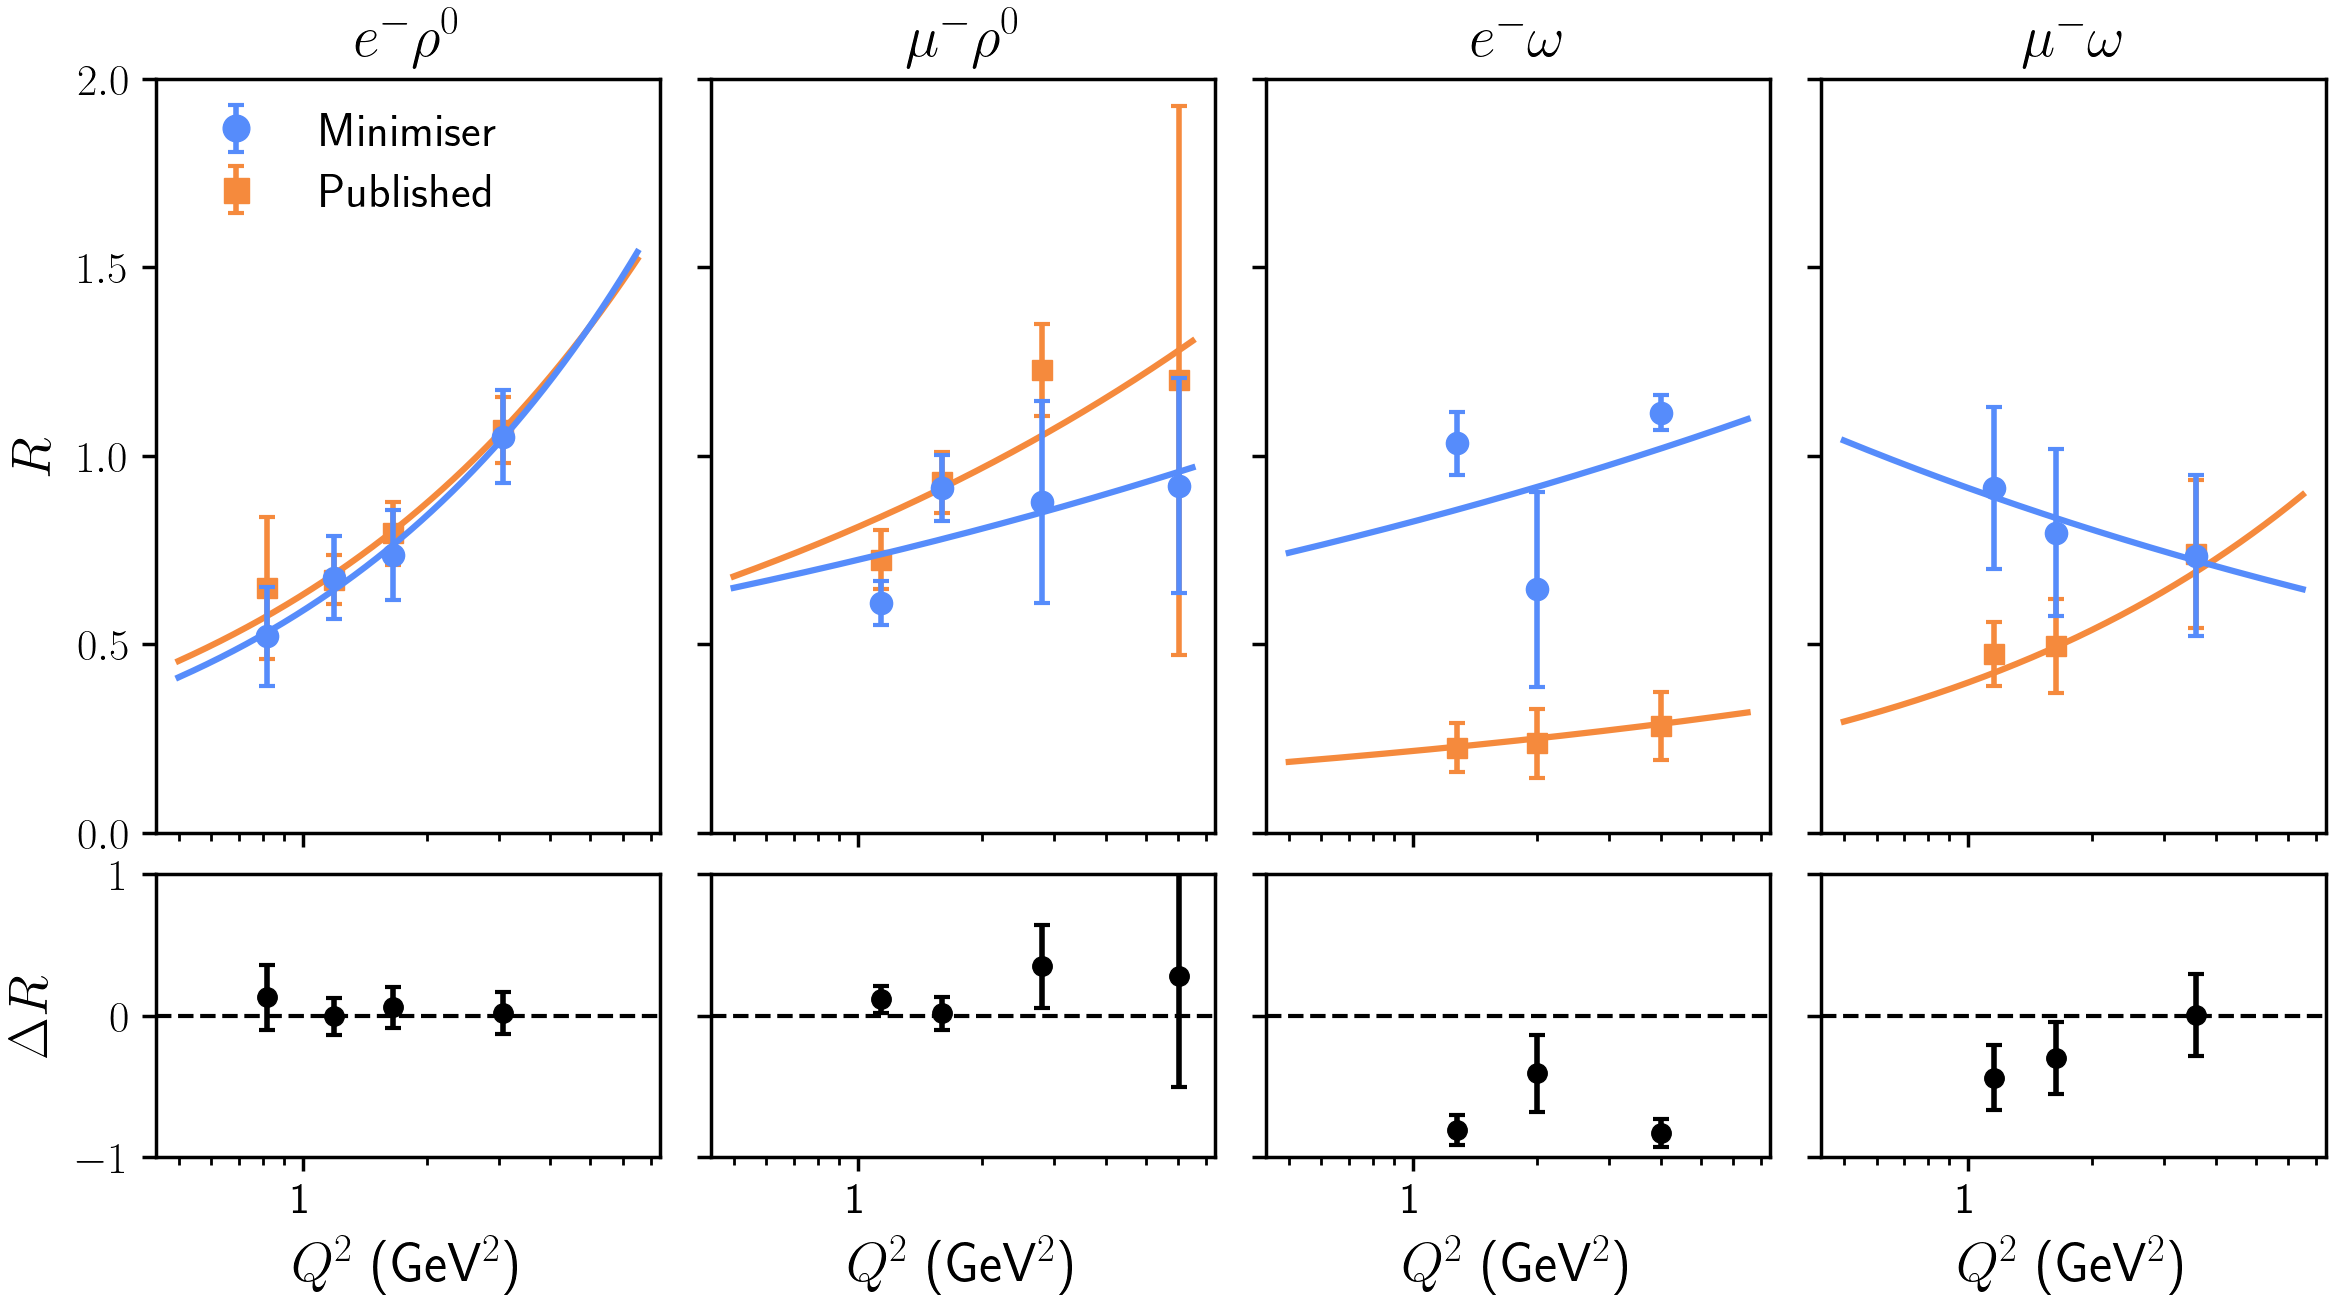

In [16]:
# ---------------------------------
# Poster-friendly plotting settings
# ---------------------------------
plt.rcParams.update({
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
})

# Fit with cuts
R_legend = ["e^-\\rho^0", "\\mu^-\\rho^0", "e^-\\omega", "\\mu^-\\omega"]
mean_and_err = np.empty((4, 2))
Q2_fit = np.linspace(0.5, 6.5, 1000)

# -------------------------------
# NEW LAYOUT FOR THE FIRST FIGURE
# -------------------------------
fig = plt.figure(figsize=(28, 14))   # larger overall canvas
gs = fig.add_gridspec(
    2, 4,
    height_ratios=[3.2, 1.2],
    hspace=0.08,
    wspace=0.10
)

axL      = fig.add_subplot(gs[0, 0])
axCL     = fig.add_subplot(gs[0, 1], sharex=axL, sharey=axL)
axCR     = fig.add_subplot(gs[0, 2], sharex=axL, sharey=axL)
axR      = fig.add_subplot(gs[0, 3], sharex=axL, sharey=axL)

axdiffL  = fig.add_subplot(gs[1, 0], sharex=axL)
axdiffCL = fig.add_subplot(gs[1, 1], sharex=axL, sharey=axdiffL)
axdiffCR = fig.add_subplot(gs[1, 2], sharex=axL, sharey=axdiffL)
axdiffR  = fig.add_subplot(gs[1, 3], sharex=axL, sharey=axdiffL)

for r in range(4):
    for i in range(bin_size[r]):
        if ((r == 2 or r == 3) and i == 3):
            continue

        df = ROOT.RDataFrame(
            "PartialWaves",
            "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/"
            + filenames[r] + "_bootstrap_" + str(i) + ".root"
        )

        df = df.Define("R", "-H_4_0_0/H_0_0_0")
        R = df.Mean("R")
        Rerr = df.StdDev("R")
        mean_and_err[i, :] = np.array([R.GetValue(), Rerr.GetValue()])

    # ----------------
    # FITS
    # ----------------
    if r == 2 or r == 3:
        # if r == 2:
        #     mean_and_err[1, 0] = 1.1
        #     mean_and_err[1, 1] = 0.05

        popt, pcov = curve_fit(
            vmd_model_omega,
            Q2[r, :3],
            mean_and_err[:3, 0],
            p0=[1, 1],
        )
        R_fit = vmd_model_omega(Q2_fit, *popt)
    else:
        popt, pcov = curve_fit(
            vmd_model_rho,
            Q2[r, :],
            mean_and_err[:, 0],
            p0=[1, 1],
        )
        R_fit = vmd_model_rho(Q2_fit, *popt)

    hermes_best = vmd_model_rho(Q2_fit, 0.56, 0.47)

    popt, pcov = curve_fit(
        vmd_model_rho,
        Q2[1, :],
        R_COMPASS[:, 0],
        p0=[1, 1],
    )
    compass_best = vmd_model_rho(Q2_fit, *popt)

    popt, pcov = curve_fit(
        vmd_model_omega,
        Q2[2, :3],
        R_OMEGA[:, 0],
        p0=[1, 1],
    )
    omega_best = vmd_model_omega(Q2_fit, *popt)

    popt, pcov = curve_fit(
        vmd_model_omega,
        Q2[3, :3],
        R_EOMEGA[:, 0],
        p0=[1, 1],
    )
    e_omega_best = vmd_model_omega(Q2_fit, *popt)

    # ----------------
    # FIRST FIGURE
    # ----------------
    if r == 0:
        p = axL.errorbar(
            Q2[r, :], mean_and_err[:, 0], yerr=mean_and_err[:, 1],
            fmt='o', markersize=16, elinewidth=4, capsize=6, capthick=3,
            zorder=5, label="Minimiser"
        )
        c = p.lines[0].get_color()
        axL.plot(Q2_fit, R_fit, '-', color=c, zorder=5, linewidth=4.5)

        p = axL.errorbar(
            Q2[r, :], R_HERMES[:, 0], yerr=R_HERMES[:, 1],
            fmt='s', markersize=15, elinewidth=4, capsize=6, capthick=3,
            label="Published"
        )
        c = p.lines[0].get_color()
        axL.plot(Q2_fit, hermes_best, '-', color=c, linewidth=4.5)

        diff = R_HERMES[:, 0] - mean_and_err[:, 0]
        diff_err = np.sqrt(R_HERMES[:, 1]**2 + mean_and_err[:, 1]**2)

    elif r == 1:
        p = axCL.errorbar(
            Q2[r, :], mean_and_err[:, 0], yerr=mean_and_err[:, 1],
            fmt='o', markersize=16, elinewidth=4, capsize=6, capthick=3,
            zorder=5
        )
        c = p.lines[0].get_color()
        axCL.plot(Q2_fit, R_fit, '-', color=c, zorder=5, linewidth=4.5)

        p = axCL.errorbar(
            Q2[r, :], R_COMPASS[:, 0], yerr=R_COMPASS[:, 1],
            fmt='s', markersize=15, elinewidth=4, capsize=6, capthick=3
        )
        c = p.lines[0].get_color()
        axCL.plot(Q2_fit, compass_best, '-', color=c, linewidth=4.5)

        diff_muon = R_COMPASS[:, 0] - mean_and_err[:, 0]
        diff_muon_err = np.sqrt(R_COMPASS[:, 1]**2 + mean_and_err[:, 1]**2)

    elif r == 2:
        p = axCR.errorbar(
            Q2[r, :3], mean_and_err[:3, 0], yerr=mean_and_err[:3, 1],
            fmt='o', markersize=16, elinewidth=4, capsize=6, capthick=3,
            zorder=5
        )
        c = p.lines[0].get_color()
        axCR.plot(Q2_fit, R_fit, '-', color=c, zorder=5, linewidth=4.5)

        p = axCR.errorbar(
            Q2[r, :3], R_EOMEGA[:, 0], yerr=R_EOMEGA[:, 1],
            fmt='s', markersize=15, elinewidth=4, capsize=6, capthick=3
        )
        c = p.lines[0].get_color()
        axCR.plot(Q2_fit, e_omega_best, '-', color=c, linewidth=4.5)

        diff_e_omega = R_EOMEGA[:, 0] - mean_and_err[:3, 0]
        diff_e_omega_err = np.sqrt(R_EOMEGA[:, 1]**2 + mean_and_err[:3, 1]**2)

    elif r == 3:
        p = axR.errorbar(
            Q2[r, :3], mean_and_err[:3, 0], yerr=mean_and_err[:3, 1],
            fmt='o', markersize=16, elinewidth=4, capsize=6, capthick=3,
            zorder=5
        )
        c = p.lines[0].get_color()
        axR.plot(Q2_fit, R_fit, '-', color=c, zorder=5, linewidth=4.5)

        p = axR.errorbar(
            Q2[r, :3], R_OMEGA[:, 0], yerr=R_OMEGA[:, 1],
            fmt='s', markersize=15, elinewidth=4, capsize=6, capthick=3
        )
        c = p.lines[0].get_color()
        axR.plot(Q2_fit, omega_best, '-', color=c, linewidth=4.5)

        diff_omega = R_OMEGA[:, 0] - mean_and_err[:3, 0]
        diff_omega_err = np.sqrt(R_OMEGA[:, 1]**2 + mean_and_err[:3, 1]**2)

# ----------------
# Titles / labels
# ----------------
axL.set_title(r"$e^- \rho^0$", pad=16)
axCL.set_title(r"$\mu^- \rho^0$", pad=16)
axCR.set_title(r"$e^- \omega$", pad=16)
axR.set_title(r"$\mu^- \omega$", pad=16)

axL.set_ylabel("$R$", labelpad=12)
axdiffL.set_ylabel(r"$\Delta R$", labelpad=12)

axdiffL.set_xlabel(r"$Q^2$ (GeV$^2$)", labelpad=10)
axdiffCL.set_xlabel(r"$Q^2$ (GeV$^2$)", labelpad=10)
axdiffCR.set_xlabel(r"$Q^2$ (GeV$^2$)", labelpad=10)
axdiffR.set_xlabel(r"$Q^2$ (GeV$^2$)", labelpad=10)

# Only one legend, on the first panel
axL.legend(
    loc="upper left",
    frameon=False,
    handlelength=2.0,
    borderpad=0.2,
    labelspacing=0.4,
    markerscale=1.2
)

# ----------------
# Bottom panels
# ----------------
axdiffL.errorbar(
    Q2[0, :], diff, yerr=diff_err,
    fmt='o', markersize=14, elinewidth=4, capsize=6, capthick=3, color="black"
)
axdiffL.axhline(0, ls='--', color="black", linewidth=3)

axdiffCL.errorbar(
    Q2[1, :], diff_muon, yerr=diff_muon_err,
    fmt='o', markersize=14, elinewidth=4, capsize=6, capthick=3, color="black"
)
axdiffCL.axhline(0, ls='--', color="black", linewidth=3)

axdiffCR.errorbar(
    Q2[2, :3], diff_e_omega, yerr=diff_e_omega_err,
    fmt='o', markersize=14, elinewidth=4, capsize=6, capthick=3, color="black"
)
axdiffCR.axhline(0, ls='--', color="black", linewidth=3)

axdiffR.errorbar(
    Q2[3, :3], diff_omega, yerr=diff_omega_err,
    fmt='o', markersize=14, elinewidth=4, capsize=6, capthick=3, color="black"
)
axdiffR.axhline(0, ls='--', color="black", linewidth=3)

# ----------------
# Limits / scales
# ----------------
axL.set_ylim(0, 2)
axL.set_yticks([0,0.5,1,1.5,2])
axdiffL.set_ylim(-1, 1)

for a in (axdiffL, axdiffCL, axdiffCR, axdiffR):
    a.set_xscale('log')
    a.xaxis.set_major_formatter('{x:g}')

# Hide duplicate tick labels on top row
axL.tick_params(labelbottom=False)
axCL.tick_params(labelbottom=False, labelleft=False)
axCR.tick_params(labelbottom=False, labelleft=False)
axR.tick_params(labelbottom=False, labelleft=False)

axdiffCL.tick_params(labelleft=False)
axdiffCR.tick_params(labelleft=False)
axdiffR.tick_params(labelleft=False)

# Thicker spines and roomier ticks
for ax in [axL, axCL, axCR, axR, axdiffL, axdiffCL, axdiffCR, axdiffR]:
    ax.tick_params(width=2.5, length=10, pad=8)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

fig.savefig(
    "RScaling_split.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    format="png"
)

plt.show()

In [ ]:
\vspace*{-1cm}
\raggedright \textbf{Angular distributions from field theory:}
\begin{align*}
    &I_{ph}(\Omega,\Phi) \equiv \frac{\diff \sigma}{\diff t \diff m_{ab}\diff\Omega\diff\Phi} = \kappa_{ph}\sum_{\lambda,\lambda',\lambda_1\lambda_2}T_{\lambda;\lambda_1\lambda_2}(\Omega)\rho^\gamma_{\lambda\lambda'}(\Phi)_T^*_{\lambda';\lambda_1\lambda_2}(\Omega)\\
    &I_{el}(\Omega,\Phi) \equiv\Gamma(Q^2,x)\frac{\diff \sigma^*}{\diff m_{ab} \diff t \diff \Omega \diff\Phi} = \kappa_{el}\sum_{\lambda,\lambda',\lambda_1\lambda_2}T_{\lambda;\lambda_1\lambda_2}(\Omega)\rho^{\gamma*}_{\lambda\lambda'}(\Phi)_T^*_{\lambda';\lambda_1\lambda_2}(\Omega)
\end{align*}